In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,cedd4_00001,0,31.651746,bald,2,18642.263164
1,1,cedd4_00001,1,31.651349,bald,2,18642.263164
2,2,cedd4_00001,2,31.495119,bald,2,18642.263164
3,3,cedd4_00001,3,31.489962,bald,2,18642.263164
4,4,cedd4_00001,4,31.436369,bald,2,18642.263164
...,...,...,...,...,...,...,...
27995,27995,cedd4_00034,995,12.158655,random,5,18913.609329
27996,27996,cedd4_00034,996,12.158655,random,5,18913.609329
27997,27997,cedd4_00034,997,12.156728,random,5,18913.609329
27998,27998,cedd4_00034,998,12.159153,random,5,18913.609329


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
23000,23000,cedd4_00030,0,32.413617,random,1,18893.259202
23001,23001,cedd4_00030,1,32.410956,random,1,18893.259202
23002,23002,cedd4_00030,2,32.410956,random,1,18893.259202
23003,23003,cedd4_00030,3,32.408909,random,1,18893.259202
23004,23004,cedd4_00030,4,32.349231,random,1,18893.259202
...,...,...,...,...,...,...,...
27995,27995,cedd4_00034,995,12.158655,random,5,18913.609329
27996,27996,cedd4_00034,996,12.158655,random,5,18913.609329
27997,27997,cedd4_00034,997,12.156728,random,5,18913.609329
27998,27998,cedd4_00034,998,12.159153,random,5,18913.609329


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

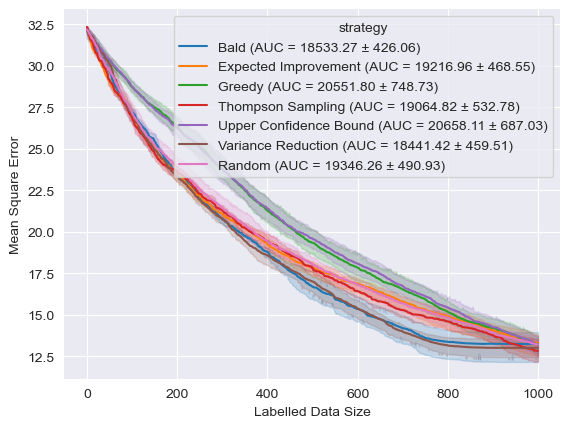

In [5]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")
# _ = plt.xticks(np.arange(0,26), np.arange(0,26)*10 + 20, rotation=45)

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)